<p style="align: center;"><img src="https://static.tildacdn.com/tild6636-3531-4239-b465-376364646465/Deep_Learning_School.png" width="400"></p>

# Домашнее задание. Обучение языковой модели с помощью LSTM (10 баллов)

Э
В этом задании Вам предстоит обучить языковую модель с помощью рекуррентной нейронной сети. В отличие от семинарского занятия, Вам необходимо будет работать с отдельными словами, а не буквами.


Установим модуль ```datasets```, чтобы нам проще было работать с данными.

In [40]:
!pip install datasets

Импорт необходимых библиотек

In [41]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from datasets import load_dataset
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.model_selection import train_test_split
import nltk

from collections import Counter
from typing import List

import seaborn
seaborn.set(palette='summer')

In [42]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [43]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## Подготовка данных

Воспользуемся датасетом imdb. В нем хранятся отзывы о фильмах с сайта imdb. Загрузим данные с помощью функции ```load_dataset```

In [44]:
# Загрузим датасет
dataset = load_dataset('imdb')

### Препроцессинг данных и создание словаря (1 балл)

Далее вам необходмо самостоятельно произвести препроцессинг данных и получить словарь или же просто ```set``` строк. Что необходимо сделать:

1. Разделить отдельные тренировочные примеры на отдельные предложения с помощью функции ```sent_tokenize``` из бибилиотеки ```nltk```. Каждое отдельное предложение будет одним тренировочным примером.
2. Оставить только те предложения, в которых меньше ```word_threshold``` слов.
3. Посчитать частоту вхождения каждого слова в оставшихся предложениях. Для деления предлоения на отдельные слова удобно использовать функцию ```word_tokenize```.
4. Создать объект ```vocab``` класса ```set```, положить в него служебные токены '\<unk\>', '\<bos\>', '\<eos\>', '\<pad\>' и vocab_size самых частовстречающихся слов.   

In [45]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [46]:
sentences = []
word_threshold = 32

all_sentences = []
for text in dataset['train']['text']:
    all_sentences.extend(sent_tokenize(text))

for sent in all_sentences:
    words = word_tokenize(sent)
    if len(words) < word_threshold:
        sentences.append(sent)

In [47]:
print("Всего предложений:", len(sentences))

Всего предложений: 198801


Посчитаем для каждого слова его встречаемость.

In [48]:
words = Counter()

for sent in sentences:
    words.update(word_tokenize(sent))


In [49]:
words.most_common(20)

[('.', 170189),
 ('the', 126124),
 (',', 114121),
 ('a', 71655),
 ('and', 68621),
 ('of', 62048),
 ('to', 59630),
 ('is', 56695),
 ('I', 46474),
 ('it', 39499),
 ('in', 38242),
 ('this', 32565),
 ('that', 31342),
 ("'s", 29190),
 ('was', 27435),
 ('The', 24587),
 ('movie', 24248),
 ('for', 19693),
 ('film', 19124),
 ('with', 18608)]

Добавим в словарь ```vocab_size``` самых встречающихся слов.

In [50]:
vocab = set()
vocab_size = 40000
vocab = {'<unk>', '<bos>', '<eos>', '<pad>'}
vocab.update([word for word, count in words.most_common(vocab_size)])

In [51]:
assert '<unk>' in vocab
assert '<bos>' in vocab
assert '<eos>' in vocab
assert '<pad>' in vocab
assert len(vocab) == vocab_size + 4

In [52]:
print("Всего слов в словаре:", len(vocab))

Всего слов в словаре: 40004


### Подготовка датасета (1 балл)

Далее, как и в семинарском занятии, подготовим датасеты и даталоадеры.

В классе ```WordDataset``` вам необходимо реализовать метод ```__getitem__```, который будет возвращать сэмпл данных по входному idx, то есть список целых чисел (индексов слов).

Внутри этого метода необходимо добавить служебные токены начала и конца последовательности, а также токенизировать соответствующее предложение с помощью ```word_tokenize``` и сопоставить ему индексы из ```word2ind```.

In [53]:
word2ind = {char: i for i, char in enumerate(vocab)}
ind2word = {i: char for char, i in word2ind.items()}

In [54]:
class WordDataset:
    def __init__(self, sentences):
        self.data = sentences
        self.unk_id = word2ind['<unk>']
        self.bos_id = word2ind['<bos>']
        self.eos_id = word2ind['<eos>']
        self.pad_id = word2ind['<pad>']

    def __getitem__(self, idx: int) -> List[int]:
        tokenized_sentence = []
        sent = self.data[idx]
        if isinstance(sent, list):
            tokens = sent
        else:
            tokens = word_tokenize(str(sent).strip())

        token_ids = [word2ind.get(tok, self.unk_id) for tok in tokens]

        tokenized_sentence = [self.bos_id] + token_ids + [self.eos_id]

        return tokenized_sentence

    def __len__(self) -> int:
        return len(self.data)

In [55]:
def collate_fn_with_padding(
    input_batch: List[List[int]], pad_id=word2ind['<pad>']) -> torch.Tensor:
    seq_lens = [len(x) for x in input_batch]
    max_seq_len = max(seq_lens)

    new_batch = []
    for sequence in input_batch:
        for _ in range(max_seq_len - len(sequence)):
            sequence.append(pad_id)
        new_batch.append(sequence)

    sequences = torch.LongTensor(new_batch).to(device)

    new_batch = {
        'input_ids': sequences[:,:-1],
        'target_ids': sequences[:,1:]
    }

    return new_batch

In [56]:
train_sentences, eval_sentences = train_test_split(sentences, test_size=0.2)
eval_sentences, test_sentences = train_test_split(sentences, test_size=0.5)

train_dataset = WordDataset(train_sentences)
eval_dataset = WordDataset(eval_sentences)
test_dataset = WordDataset(test_sentences)

batch_size = 128

train_dataloader = DataLoader(
    train_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

eval_dataloader = DataLoader(
    eval_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

test_dataloader = DataLoader(
    test_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

In [57]:
pad_id = word2ind['<pad>']

## Обучение и архитектура модели

Вам необходимо на практике проверить, что влияет на качество языковых моделей. В этом задании нужно провести серию экспериментов с различными вариантами языковых моделей и сравнить различия в конечной перплексии на тестовом множестве.

Возмоэные идеи для экспериментов:

* Различные RNN-блоки, например, LSTM или GRU. Также можно добавить сразу несколько RNN блоков друг над другом с помощью аргумента num_layers. Вам поможет официальная документация [здесь](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html)
* Различные размеры скрытого состояния. Различное количество линейных слоев после RNN-блока. Различные функции активации.
* Добавление нормализаций в виде Dropout, BatchNorm или LayerNorm
* Различные аргументы для оптимизации, например, подбор оптимального learning rate или тип алгоритма оптимизации SGD, Adam, RMSProp и другие
* Любые другие идеи и подходы

После проведения экспериментов необходимо составить таблицу результатов, в которой описан каждый эксперимент и посчитана перплексия на тестовом множестве.

Учтите, что эксперименты, которые различаются, например, только размером скрытого состояния или количеством линейных слоев считаются, как один эксперимент.

Успехов!

### Функция evaluate (1 балл)

Заполните функцию ```evaluate```

In [58]:
def evaluate(model, criterion, dataloader) -> float:
    model.eval()
    perplexity = []
    with torch.no_grad():
        for batch in dataloader:
            logits = model(batch['input_ids']).flatten(start_dim=0, end_dim=1) # Посчитайте логиты предсказаний следующих слов
            loss = criterion(logits, batch['target_ids'].flatten())
            perplexity.append(torch.exp(loss).item())

    perplexity = sum(perplexity) / len(perplexity)

    return perplexity

### Train loop (1 балл)

Напишите функцию для обучения модели.

In [59]:
def train_model(
        model,
        train_dataloader,
        eval_dataloader,
        criterion,
        optimizer,
        num_epoch,
        report_epoch=10
        ):
    losses = []
    perplexities = []

    for epoch in range(num_epoch):
        epoch_losses = []
        model.train()
        for batch in tqdm(train_dataloader, desc=f'Training epoch {epoch}:'):
            optimizer.zero_grad()
            logits = model(batch['input_ids']).flatten(start_dim=0, end_dim=1)
            loss = criterion(
                logits, batch['target_ids'].flatten())
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())

        losses.append(sum(epoch_losses) / len(epoch_losses))
        perplexities.append(evaluate(model, criterion, eval_dataloader))
        if epoch % report_epoch == 0:
            print(f"Espoch loss: {losses[-1]},\nEpoch perplexity: {perplexities[-1]}")

    results_dict = {
        'model': model,
        'losses': losses,
        'preplexities': perplexities
    }
    return results_dict


### Первый эксперимент (2 балла)

Определите архитектуру модели и обучите её.

In [60]:
class LanguageModel(nn.Module):
    def __init__(self, vocab_size: int, pad_id: int,
                 embed_dim: int = 256, hidden_dim: int = 512,
                 num_layers: int = 1, dropout: float = 0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id)
        self.rnn = nn.GRU(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, vocab_size)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        x = self.embedding(input_batch)                 # [B, T, E]
        x, _ = self.rnn(x)                              # [B, T, H]
        x = self.dropout(self.linear(self.non_lin(x)))  # [B, T, H]
        logits = self.projection(self.non_lin(x))       # [B, T, V]
        return logits

        return

In [61]:
model_1 = LanguageModel(vocab_size=len(word2ind), pad_id=pad_id).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)
optimizer = torch.optim.Adam(model_1.parameters())

In [63]:
exp_1 = train_model(
        model_1,
        train_dataloader,
        eval_dataloader,
        criterion,
        optimizer,
        num_epoch=20,
        report_epoch=1)

Training epoch 0::   0%|          | 0/1243 [00:00<?, ?it/s]

Espoch loss: 5.268111384308156,
Epoch perplexity: 111.48728236882076


Training epoch 1::   0%|          | 0/1243 [00:00<?, ?it/s]

Espoch loss: 4.623850025290553,
Epoch perplexity: 81.217034844358


Training epoch 2::   0%|          | 0/1243 [00:00<?, ?it/s]

...

Espoch loss: 3.016451334627233,
Epoch perplexity: 40.120405550629016


Training epoch 18::   0%|          | 0/1243 [00:00<?, ?it/s]

Espoch loss: 2.98908113972947,
Epoch perplexity: 40.14551814213069


Training epoch 19::   0%|          | 0/1243 [00:00<?, ?it/s]

Espoch loss: 2.961666088572262,
Epoch perplexity: 40.115409556503


In [68]:
losses = exp_1['losses']
perplexities = exp_1['preplexities']  # была опечатка

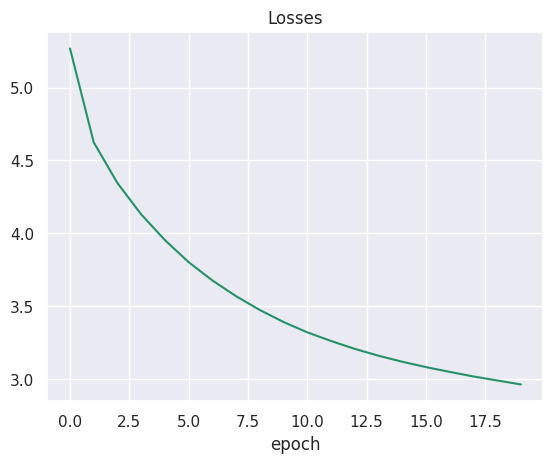

In [66]:
plt.plot(np.arange(len(losses)), losses)
plt.title('Losses')
plt.xlabel("epoch")
plt.show()

plt.plot(np.arange(len(perplexities)), perplexities)
plt.title('Perplexity')
plt.xlabel("epoch")
plt.show()

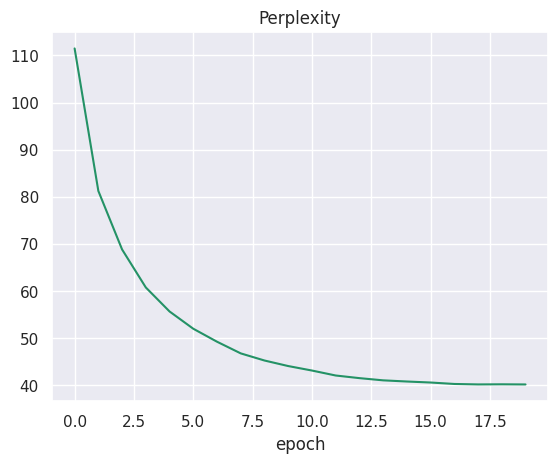

In [99]:
import torch
from nltk.tokenize import word_tokenize

def generate_sequence(model, starting_seq: str, max_seq_len: int = 256, device: str = None) -> str:
    if device is None:
        device = next(model.parameters()).device

    model = model.to(device)
    model.eval()

    ids = [word2ind['<bos>']] + [word2ind.get(tok, word2ind['<unk>'])
                                 for tok in word_tokenize(starting_seq)]
    input_ids = torch.tensor(ids, dtype=torch.long, device=device).unsqueeze(0)  # [1, T]

    with torch.no_grad():
        for _ in range(max_seq_len):
            logits = model(input_ids)           # [1, T, V]
            next_token_logits = logits[0, -1]   # [V]
            next_id = torch.argmax(next_token_logits, dim=-1)  # scalar id

            input_ids = torch.cat([input_ids, next_id.view(1, 1)], dim=1)

            if next_id.item() == word2ind['<eos>']:
                break

    seq = input_ids.squeeze(0).tolist()
    if word2ind['<eos>'] in seq:
        end = seq.index(word2ind['<eos>'])
    else:
        end = len(seq)
    content = seq[1:end]  # пропускаем <bos>

    words = [ind2word[i] for i in content]
    return ' '.join(words)


In [93]:
import random
random.choice(list(word2ind.keys()))

'triangles'

In [181]:
generate_sequence(exp_1['model'], starting_seq='Hello World')

'Hello World War II is a new new movie , it is a masterpiece .'

### Второй эксперимент (2 балла)

Попробуйте что-то поменять в модели или в пайплайне обучения, идеи для экспериментов можно подсмотреть выше.

In [111]:
import torch
import torch.nn as nn

class LanguageModelTwo(nn.Module):
    def __init__(self, vocab_size: int, pad_id: int,
                 embed_dim: int = 256, hidden_dim: int = 512,
                 num_layers: int = 2, dropout: float = 0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id)

        self.rnn = nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.norm = nn.LayerNorm(hidden_dim)

        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.act = nn.GELU()
        self.dropout = nn.Dropout(p=dropout)

        self.h2e = nn.Linear(hidden_dim, embed_dim)
        self.projection = nn.Linear(embed_dim, vocab_size, bias=False)

        self.projection.weight = self.embedding.weight

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        x = self.embedding(input_batch)                 # [B, T, E]
        x, _ = self.rnn(x)                              # [B, T, H]
        x = self.norm(x)                                # [B, T, H]
        x = self.dropout(self.linear(self.act(x)))      # [B, T, H]
        x = self.act(self.h2e(x))                       # [B, T, E]
        logits = self.projection(x)                     # [B, T, V]
        return logits


In [112]:
model_2 = LanguageModelTwo(vocab_size=len(word2ind), pad_id=pad_id).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)
optimizer = torch.optim.Adam(model_2.parameters())

In [114]:
exp_2 = train_model(
        model_2,
        train_dataloader,
        eval_dataloader,
        criterion,
        optimizer,
        num_epoch=10,
        report_epoch=1)

Training epoch 0::   0%|          | 0/1243 [00:00<?, ?it/s]

Espoch loss: 5.633880131108475,
Epoch perplexity: 160.50824833775425


Training epoch 1::   0%|          | 0/1243 [00:00<?, ?it/s]

Espoch loss: 4.9804863864533475,
Epoch perplexity: 121.45989665224131


Training epoch 2::   0%|          | 0/1243 [00:00<?, ?it/s]

...

Espoch loss: 4.308265568456243,
Epoch perplexity: 72.68841148189902


Training epoch 8::   0%|          | 0/1243 [00:00<?, ?it/s]

Espoch loss: 4.254770527131502,
Epoch perplexity: 69.91208514160785


Training epoch 9::   0%|          | 0/1243 [00:00<?, ?it/s]

Espoch loss: 4.207494028709823,
Epoch perplexity: 67.6111450097122


In [116]:
losses = exp_2['losses']
perplexities = exp_2['preplexities']

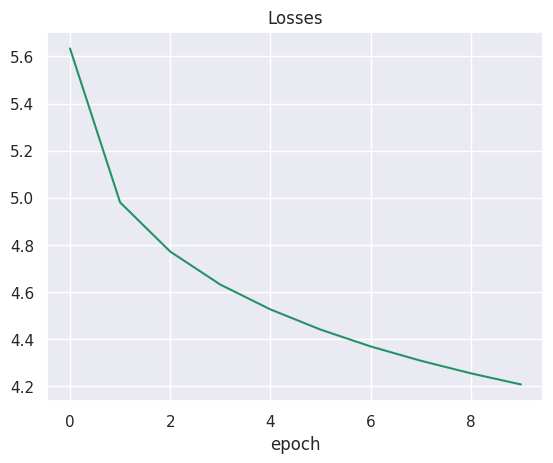

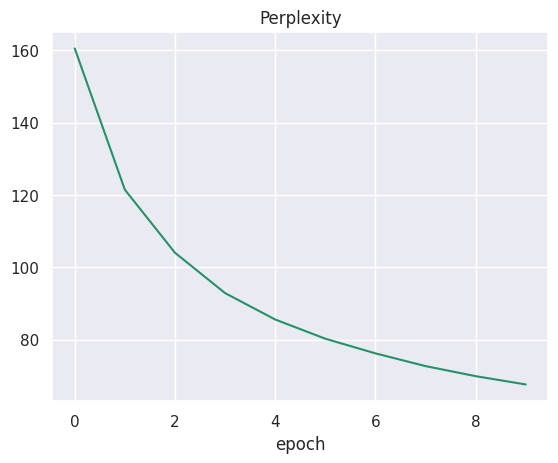

In [118]:
plt.plot(np.arange(len(losses)), losses)
plt.title('Losses')
plt.xlabel("epoch")
plt.show()

plt.plot(np.arange(len(perplexities)), perplexities)
plt.title('Perplexity')
plt.xlabel("epoch")
plt.show()

### Третий эксперимент

In [129]:
class LanguageModelThree(nn.Module):
    def __init__(self, vocab_size: int, pad_id: int,
                 embed_dim: int = 256, hidden_dim: int = 512,
                 num_layers: int = 1, dropout: float = 0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id)

        self.rnn = nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )

        self.norm = nn.LayerNorm(hidden_dim)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.act = nn.GELU()
        self.dropout = nn.Dropout(p=dropout)

        self.projection = nn.Linear(hidden_dim, vocab_size)

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        x = self.embedding(input_batch)
        x, _ = self.rnn(x)
        x = self.norm(x)
        x = self.dropout(self.act(self.linear(x)))
        logits = self.projection(x)
        return logits


In [130]:
model_3 = LanguageModelThree(vocab_size=len(word2ind), pad_id=pad_id).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)
optimizer = torch.optim.Adam(model_3.parameters())

In [131]:
exp_2 = train_model(
        model_3,
        train_dataloader,
        eval_dataloader,
        criterion,
        optimizer,
        num_epoch=10,
        report_epoch=1)

Training epoch 0::   0%|          | 0/1243 [00:00<?, ?it/s]

Espoch loss: 5.127804708979538,
Epoch perplexity: 99.38313103949548


Training epoch 1::   0%|          | 0/1243 [00:00<?, ?it/s]

Espoch loss: 4.5244537949657975,
Epoch perplexity: 72.52980365532245


Training epoch 2::   0%|          | 0/1243 [00:00<?, ?it/s]

...

Espoch loss: 3.4034037960218213,
Epoch perplexity: 37.98054230934251


Training epoch 8::   0%|          | 0/1243 [00:00<?, ?it/s]

Espoch loss: 3.3138201062178667,
Epoch perplexity: 36.5214347372951


Training epoch 9::   0%|          | 0/1243 [00:00<?, ?it/s]

Espoch loss: 3.238214414539782,
Epoch perplexity: 35.38584578083289


In [168]:
losses = exp_3['losses']
perplexities = exp_3['preplexities']

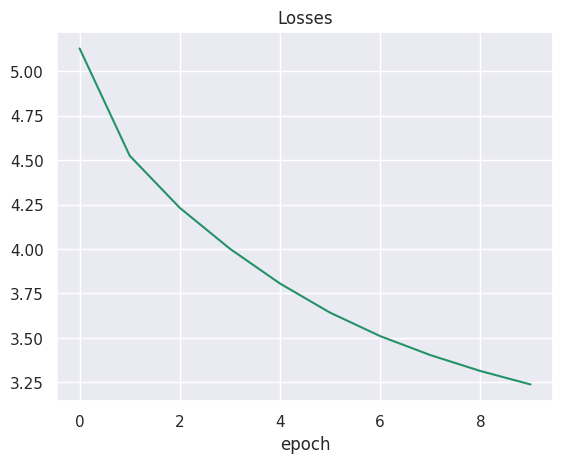

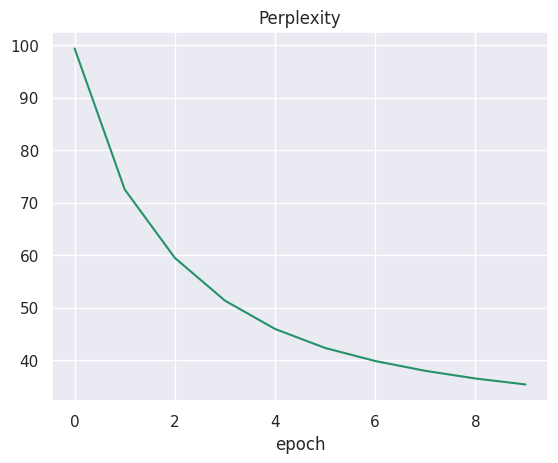

In [169]:
plt.plot(np.arange(len(losses)), losses)
plt.title('Losses')
plt.xlabel("epoch")
plt.show()

plt.plot(np.arange(len(perplexities)), perplexities)
plt.title('Perplexity')
plt.xlabel("epoch")
plt.show()

In [180]:
generate_sequence(exp_3['model'], starting_seq='Hello World')

"Hello World War II , I 'm not a big fan of the conservative epics , but I 'm not sure what the hell was going on ."

### Отчет (2 балла)

Опишите проведенные эксперименты. Сравните перплексии полученных моделей. Предложите идеи по улучшению качества моделей.

## Эксперимент 1: модель из семинара (буквы -> слова)

**Архитектура:**
GRU с одним слоем, embed_dim=256, hidden_dim=512, dropout=0.1, активация Tanh.

**Идея:** просто применить архитектуру из семинара, адаптировать с симфолов на слова и проверить, как она поведет себя.

**Результаты:**

* Перплексия с 111 снизилась до примерно 40 за 20 эпох.
* Генерация уже дает внятные фразы, но местами с повторениями. Пример:
>Hello World War II is a new new movie , it is a masterpiece .

**Вывод:**
Модель обучается стабильно, но интересно попробовать лучше, потому что предложения были с повторами и не очень осмысленные

## Эксперимент 2: двухслойный GRU с weight tying

**Архитектура:**
GRU с двумя слоями, слой нормализации LayerNorm, GELU, weight tying и проекция из hidden_dim в embed_dim.

**Результаты:**

* Перплексия снизилась с 160 до примерно 67 за 10 эпох.
* Финальная перплексия оказалась хуже, чем у первой.

**Вывод:**
Сложная архитектура не дала улучшения. Вероятно, weight tying и лишняя проекция помешали эффективному обучению на словах.

## Эксперимент 3: упрощенная архитектура с LayerNorm и GELU

**Архитектура:**
Один слой GRU, LayerNorm после RNN, GELU вместо Tanh, dropout 0.2.

**Результаты:**

* Перплексия с 99 упала до примерно 35 за 10 эпох.
* Модель обучается стабильно, текст генерации выглядит чуть более осмысленно.
  Пример:
> Hello World War II , I 'm not a big fan of the conservative epics , but I 'm not sure what the hell was going on .

**Вывод:**
Простая архитектура с нормализацией и GELU оказалась лучшей. Оптимальное сочетание простоты и регуляризации.

## Идеи для улучшения

1. Попробовать LSTM вместо GRU.
2. Использовать dropout на эмбеддингах.
3. Подобрать learning rate и добавить gradient clipping.
4. Добавить больше данных или увеличить длину контекста при обучении.


In [182]:
2+2

4